# Расчёт справедливой стоимости участия в прибыли
## Паевой договор страхования жизни с инвестированием в строящуюся недвижимость

**Итоговый расчётный ноутбук.** Проходит весь путь: реальные данные Росстата
→ калибровка → полная модель → справедливая стоимость участия методом
глубокого хеджирования → анализ чувствительности и стресс-тесты.
Результаты этого ноутбука образуют численную основу главы 4 работы.

### Содержание
1. Данные и устранение сглаживания (Гелтнер) — реальная волатильность
2. Калибровка параметров (рынок, контракт, риск незавершения по ЕРЗ)
3. Полная модель договора (скачок незавершения, базисный риск, смертность,
   два режима премии)
4. Верификация (Блэк–Шоулз и Monte-Carlo baseline)
5. **Главный расчёт:** $V_0^{\mathrm{part}}=\pi(\xi_\alpha)-\pi(\xi_0)$
6. Анализ чувствительности и стресс-тесты
7. Сводка результатов для главы 4

> **Данные.** Положите рядом `realty_index.csv` (колонка `price`) — ряд
> цен первичного жилья РФ, собранный из публикаций Росстата. При отсутствии
> файла используется синтетический ряд (помечается в выводе).

## 0. Импорт и устройство

In [1]:
import numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
import os
from math import log, sqrt, exp
from scipy.stats import norm
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Устройство:", device)
if device=="cuda": print("GPU:", torch.cuda.get_device_name(0))

Устройство: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


## 1. Данные и устранение сглаживания (Гелтнер)

Оценочные индексы недвижимости занижают волатильность из-за сглаживания
(п. 1.6). Десглаживание обращает AR(1)-фильтр
$r^{\mathrm{true}}_t=(r^{\mathrm{obs}}_t-\phi r^{\mathrm{obs}}_{t-1})/(1-\phi)$.
Десглаженная волатильность и средний рост далее используются как параметры
модели недвижимости.

Реальные данные: realty_index.csv, 21 кварталов (2021Q1..2026Q1)
phi=0.671
sigma наблюдаемая (год)  = 0.0437
sigma десглаженная (год) = 0.0879  <-- используем в модели
оценка mu (год)          = 0.1324
повышение волатильности  = 2.01x


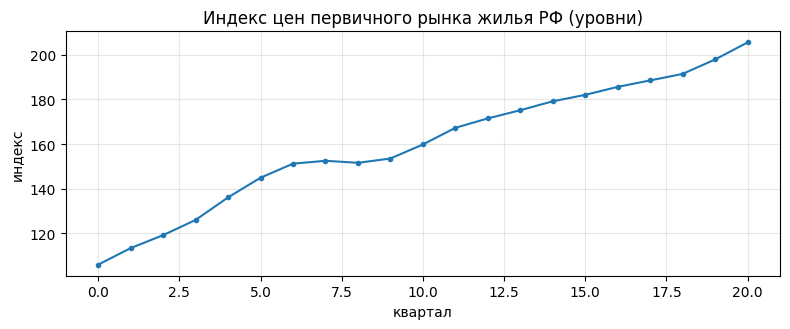

In [3]:
DATA_FILE="realty_index.csv"; FREQ=4   # квартальные данные

def load_prices():
    if os.path.exists(DATA_FILE):
        import pandas as pd
        df=pd.read_csv(DATA_FILE)
        col='price' if 'price' in df.columns else df.columns[-1]
        print(f"Реальные данные: {DATA_FILE}, {len(df)} кварталов "
              f"({df.iloc[0,0]}..{df.iloc[-1,0]})")
        return df[col].to_numpy(float), True
    rng=np.random.default_rng(42); n=60
    tr=rng.normal(0.02,0.06,n); obs=np.zeros(n); obs[0]=tr[0]
    for t in range(1,n): obs[t]=0.6*obs[t-1]+0.4*tr[t]
    print("ФАЙЛ НЕ НАЙДЕН -> синтетика (подставьте realty_index.csv)")
    return 100*np.exp(np.cumsum(obs)), False

def geltner(prices):
    lr=np.diff(np.log(prices))
    phi=np.cov(lr[:-1],lr[1:],bias=True)[0,1]/np.var(lr[:-1])
    phi=float(np.clip(phi,-0.99,0.99))
    rt=(lr[1:]-phi*lr[:-1])/(1-phi)
    return lr.std(ddof=1), rt.std(ddof=1), phi, lr.mean()

prices, is_real = load_prices()
so,st,phi,mu_q = geltner(prices)
SIGMA_OBS  = so*sqrt(FREQ)
SIGMA_TRUE = st*sqrt(FREQ)         # <- ключевой параметр модели
MU_EST     = mu_q*FREQ
print(f"phi={phi:.3f}")
print(f"sigma наблюдаемая (год)  = {SIGMA_OBS:.4f}")
print(f"sigma десглаженная (год) = {SIGMA_TRUE:.4f}  <-- используем в модели")
print(f"оценка mu (год)          = {MU_EST:.4f}")
print(f"повышение волатильности  = {SIGMA_TRUE/SIGMA_OBS:.2f}x")

plt.figure(figsize=(8,3.4))
plt.plot(prices, marker='o', ms=3)
plt.title("Индекс цен первичного рынка жилья РФ (уровни)")
plt.xlabel("квартал"); plt.ylabel("индекс"); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 2. Калибровка параметров

Волатильность и снос недвижимости взяты из п. 1 (десглаженные, реальные).
Интенсивность незавершения $\lambda$ калибрована по доле проблемных
объектов в реестре ЕРЗ/ДОМ.РФ относительно числа строящихся домов
(базовый сценарий — эпоха эскроу-счетов). Доля возврата $\eta$ принята из
логики механизма эскроу.

In [4]:
# --- рынок ---
S0=1.0
SIGMA = float(SIGMA_TRUE)      # реальная десглаженная волатильность
r=0.05                          # безрисковая ставка (постоянная)
T=10; N=T*12; DT=1/12           # горизонт 10 лет, помесячно
# --- риск незавершения (ЕРЗ) ---
LAM=0.02                        # ~2% проблемных в год (базовый, эскроу-эпоха)
ETA=0.90                        # доля возврата при незавершении (эскроу)
# --- базисный риск (прокси недвижимости) ---
RHO_H=0.8                       # корреляция торгуемого прокси с недвижимостью
SIG_H=SIGMA+0.02                # волатильность прокси (близка к активу)
# --- контракт ---
x_age=40; g=0.02; ALPHA=0.6; beta=0.95; P=1.0; SA=0.0
# --- обучение ---
M=15000; EPOCHS=200; LR=1e-3; HID=64; GAMMA=2.0
K=1.0
print(f"SIGMA(реальн.)={SIGMA:.4f}  LAM={LAM}  ETA={ETA}  RHO_H={RHO_H}")
print(f"возраст={x_age}  T={T}  alpha={ALPHA}  g={g}  gamma={GAMMA}")

SIGMA(реальн.)=0.0879  LAM=0.02  ETA=0.9  RHO_H=0.8
возраст=40  T=10  alpha=0.6  g=0.02  gamma=2.0


## 3. Полная модель договора

Смертность (закон Гомпертца–Мейкема, параметры согласованы с порядком
величин таблиц Росстата), аннуитет дожития и эквивалентный ежегодный взнос
(принцип эквивалентности), фонд и гарантия для обоих режимов, выплата
$\xi$ с участием и возвратом при незавершении.

In [5]:
# смертность
GM_A,GM_B,GM_C=0.0002,2.5e-5,1.10
def qx(age): return min(GM_A+GM_B*GM_C**age,1.0)
def kpx(k):
    p=1.0
    for j in range(k): p*=(1-qx(x_age+j))
    return p
def annuity_due():
    v=exp(-r); return sum(v**k*kpx(k) for k in range(T))

P0_SINGLE=beta*P
AANN=annuity_due()
P_ANN=P0_SINGLE/AANN
print(f"ä={AANN:.4f}  P0={P0_SINGLE:.4f}  P_ann={P_ANN:.4f}  "
      f"(P_ann*ä={P_ANN*AANN:.4f})  P(дожить)={kpx(T):.4f}")

ä=8.0128  P0=0.9500  P_ann=0.1186  (P_ann*ä=0.9500)  P(дожить)=0.9801


In [6]:
def simulate_market(M):
    Z=torch.randn(M,N,2,device=device)
    Zs=Z[:,:,0]; Zh=RHO_H*Z[:,:,0]+sqrt(1-RHO_H**2)*Z[:,:,1]
    logS=torch.zeros(M,N+1,device=device); logH=torch.zeros(M,N+1,device=device)
    jc=LAM*(1-ETA); one=torch.tensor(1.0,device=device); et=torch.tensor(ETA,device=device)
    theta=torch.full((M,),N+1,dtype=torch.long,device=device)
    for i in range(N):
        jump=(torch.rand(M,device=device)<1-exp(-LAM*DT))
        nj=jump&(theta>N); theta[nj]=i
        logS[:,i+1]=logS[:,i]+(r-0.5*SIGMA**2+jc)*DT+SIGMA*sqrt(DT)*Zs[:,i]+torch.log(torch.where(jump,et,one))
        logH[:,i+1]=logH[:,i]+(r-0.5*SIG_H**2)*DT+SIG_H*sqrt(DT)*Zh[:,i]
    return torch.exp(logS),torch.exp(logH),theta

def sample_death(M):
    alive=torch.ones(M,dtype=torch.bool,device=device)
    K_=torch.full((M,),T+1,dtype=torch.long,device=device)
    for k in range(T):
        die=(torch.rand(M,device=device)<qx(x_age+k))&alive
        K_[die]=k+1; alive=alive&(~die)
    return K_

def fund_guar(S,mode):
    M=S.shape[0]; F=torch.zeros(M,N+1,device=device); G=torch.zeros(M,N+1,device=device)
    tg=torch.arange(N+1,device=device).float()*DT
    if mode=='single':
        F=P0_SINGLE*S/S[:,0:1]; G=(P0_SINGLE*torch.exp(g*tg)).expand(M,N+1)
    else:
        for k in range(T):
            cm=k*12; ratio=torch.zeros(M,N+1,device=device)
            ratio[:,cm:]=P_ANN*S[:,cm:]/S[:,cm:cm+1]; F=F+ratio
            tcm=cm*DT
            G=G+torch.where(tg>=tcm,P_ANN*torch.exp(g*(tg-tcm)),torch.zeros_like(tg)).expand(M,N+1)
    return F,G

def contrib(mode,month):
    return P0_SINGLE if mode=='single' else P_ANN*min(month//12+1,T)

def payoff(S,theta,K_,mode,alpha):
    M=S.shape[0]; F,G=fund_guar(S,mode)
    disc=torch.exp(-r*torch.arange(N+1,device=device).float()*DT)
    pm=torch.where(K_<=T,K_*12,torch.full_like(K_,N)).clamp(max=N).long()
    Fp=F[torch.arange(M),pm]; Gp=G[torch.arange(M),pm]
    Phi=Gp+alpha*torch.clamp(Fp-Gp,min=0.0)
    failed=theta<=pm; ret=torch.empty(M,device=device)
    for mth in pm.unique():
        msk=(pm==mth); ret[msk]=ETA*contrib(mode,int(mth))
    Psi=torch.where(failed,ret,Phi)
    if SA>0: Psi=torch.where(K_<=T,torch.clamp(Psi,min=SA),Psi)
    return Psi*disc[pm]

class HedgeNet(nn.Module):
    def __init__(s,hid=HID):
        super().__init__()
        s.net=nn.Sequential(nn.Linear(4,hid),nn.ReLU(),
                            nn.Linear(hid,hid),nn.ReLU(),nn.Linear(hid,1))
    def forward(s,t,lH,lS,fund):
        return s.net(torch.stack([t,lH,lS,fund],-1)).squeeze(-1)

def train_full(mode,alpha,M=M,epochs=EPOCHS,gamma=GAMMA,lr=LR,seed=1):
    torch.manual_seed(seed)
    net=HedgeNet().to(device); opt=torch.optim.Adam(net.parameters(),lr=lr)
    times=torch.arange(N,device=device).float()/N
    dfac=torch.exp(-r*torch.arange(N+1,device=device).float()*DT)
    for ep in range(epochs):
        S,H,theta=simulate_market(M); K_=sample_death(M)
        F,G=fund_guar(S,mode); Htil=H*dfac
        gains=torch.zeros(M,device=device)
        for i in range(N):
            d=net(times[i].expand(M),torch.log(H[:,i]),torch.log(S[:,i]),
                  torch.log(F[:,i].clamp(min=1e-6)))
            gains=gains+d*(Htil[:,i+1]-Htil[:,i])
        xi=payoff(S,theta,K_,mode,alpha); X=gains-xi
        loss=(1/gamma)*torch.logsumexp(-gamma*X,0)-(1/gamma)*log(M)
        opt.zero_grad(); loss.backward(); opt.step()
    return loss.item()
print("модель и обучение готовы")

модель и обучение готовы


## 4. Верификация

Контроль корректности: (а) Блэк–Шоулз для колла; (б) Monte-Carlo
risk-neutral оценка (при $\lambda=0$ совпадает с BS). MC служит ориентиром
naive-цены без хеджа.

In [7]:
def bs_call(S0,K,r,sigma,T):
    d1=(log(S0/K)+(r+0.5*sigma**2)*T)/(sigma*sqrt(T)); d2=d1-sigma*sqrt(T)
    return S0*norm.cdf(d1)-K*exp(-r*T)*norm.cdf(d2)
def mc_call(S0,K,r,sigma,T,lam,eta,M=200000,seed=0):
    rng=np.random.default_rng(seed); n=30; dt=T/n
    lg=np.full(M,log(S0)); jc=lam*(1-eta)
    for i in range(n):
        Z=rng.standard_normal(M); jp=rng.random(M)<(1-exp(-lam*dt))
        lg+=(r-0.5*sigma**2+jc)*dt+sigma*sqrt(dt)*Z; lg[jp]+=log(eta)
    pay=np.maximum(np.exp(lg)-K,0.0)
    return exp(-r*T)*pay.mean(), exp(-r*T)*pay.std(ddof=1)/sqrt(M)

print("Верификация на горизонте 1 год, sigma=реальная:")
print(f"  BS (lambda=0):    {bs_call(1,1,r,SIGMA,1.0):.5f}")
p,se=mc_call(1,1,r,SIGMA,1.0,0.0,ETA); print(f"  MC (lambda=0):    {p:.5f} +/- {se:.5f}")
p,se=mc_call(1,1,r,SIGMA,1.0,LAM,ETA); print(f"  MC (lambda={LAM}): {p:.5f} +/- {se:.5f}")

Верификация на горизонте 1 год, sigma=реальная:
  BS (lambda=0):    0.06396
  MC (lambda=0):    0.06390 +/- 0.00015
  MC (lambda=0.02): 0.06431 +/- 0.00016


## 5. Главный расчёт — справедливая стоимость участия

$V_0^{\mathrm{part}}=\pi(\xi_\alpha)-\pi(\xi_0)$ на полной модели с реальной
волатильностью, для обоих режимов уплаты премии (премии уравнены по
принципу эквивалентности — величины сопоставимы).

[single] pi(xi_alpha)=0.83201  pi(xi_0)=0.67693  V_part=0.15509
[annual] pi(xi_alpha)=0.87126  pi(xi_0)=0.77659  V_part=0.09467


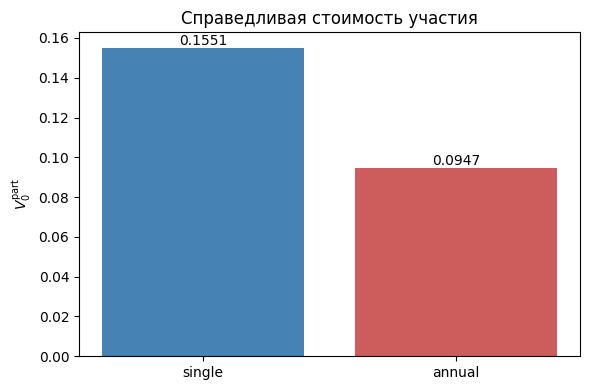

In [8]:
main_results={}
for mode in ['single','annual']:
    pa=train_full(mode,ALPHA)
    p0=train_full(mode,0.0)
    main_results[mode]=dict(pi_alpha=pa, pi_0=p0, V_part=pa-p0)
    print(f"[{mode:6}] pi(xi_alpha)={pa:.5f}  pi(xi_0)={p0:.5f}  "
          f"V_part={pa-p0:.5f}")

modes=list(main_results); vparts=[main_results[m]['V_part'] for m in modes]
plt.figure(figsize=(6,4))
b=plt.bar(modes,vparts,color=['steelblue','indianred'])
plt.ylabel(r"$V_0^{\mathrm{part}}$"); plt.title("Справедливая стоимость участия")
for i,v in enumerate(vparts): plt.text(i,v,f"{v:.4f}",ha='center',va='bottom')
plt.tight_layout(); plt.show()

## 6. Анализ чувствительности и стресс-тесты

Используем компактную модель неполного рынка (jump + базисный риск, 1 год)
как быстрый движок — эффекты выражены чётко, обучение быстрое.

In [9]:
Tc=1.0; Nc=30; DTc=Tc/Nc
def sim_c(M,sigma,lam,rho_h):
    Z=torch.randn(M,Nc,2,device=device)
    Zs=Z[:,:,0]; Zh=rho_h*Z[:,:,0]+sqrt(1-rho_h**2)*Z[:,:,1]
    lS=torch.zeros(M,Nc+1,device=device); lH=torch.zeros(M,Nc+1,device=device)
    jc=lam*(1-ETA); one=torch.tensor(1.0,device=device); et=torch.tensor(ETA,device=device)
    for i in range(Nc):
        jp=(torch.rand(M,device=device)<1-exp(-lam*DTc))
        lS[:,i+1]=lS[:,i]+(r-0.5*sigma**2+jc)*DTc+sigma*sqrt(DTc)*Zs[:,i]+torch.log(torch.where(jp,et,one))
        lH[:,i+1]=lH[:,i]+(r-0.5*(sigma+0.02)**2)*DTc+(sigma+0.02)*sqrt(DTc)*Zh[:,i]
    return torch.exp(lS),torch.exp(lH)
class NetC(nn.Module):
    def __init__(s,hid=64):
        super().__init__(); s.net=nn.Sequential(nn.Linear(3,hid),nn.ReLU(),
            nn.Linear(hid,hid),nn.ReLU(),nn.Linear(hid,1))
    def forward(s,t,lH,lS): return s.net(torch.stack([t,lH,lS],-1)).squeeze(-1)
def price_c(sigma=SIGMA,lam=LAM,rho_h=RHO_H,gamma=GAMMA,alpha=1.0,M=12000,epochs=150,seed=1):
    torch.manual_seed(seed); net=NetC().to(device); opt=torch.optim.Adam(net.parameters(),lr=1e-3)
    times=torch.arange(Nc,device=device).float()/Nc
    disc=exp(-r*Tc); dfac=torch.exp(-r*torch.arange(Nc+1,device=device).float()*DTc)
    for ep in range(epochs):
        S,H=sim_c(M,sigma,lam,rho_h); Htil=H*dfac; gains=torch.zeros(M,device=device)
        for i in range(Nc):
            d=net(times[i].expand(M),torch.log(H[:,i]),torch.log(S[:,i]))
            gains=gains+d*(Htil[:,i+1]-Htil[:,i])
        X=gains-alpha*torch.clamp(S[:,-1]-K,min=0.0)*disc
        loss=(1/gamma)*torch.logsumexp(-gamma*X,0)-(1/gamma)*log(M)
        opt.zero_grad(); loss.backward(); opt.step()
    return loss.item()

по gamma:
  0.5: 0.06517
  1.0: 0.06569
  2.0: 0.06673
  5.0: 0.06986
по lambda:
  0.0: 0.06610
  0.02: 0.06673
  0.05: 0.06762
  0.1: 0.06866
по alpha:
  0.25: 0.01630
  0.5: 0.03285
  0.75: 0.04966
  1.0: 0.06673


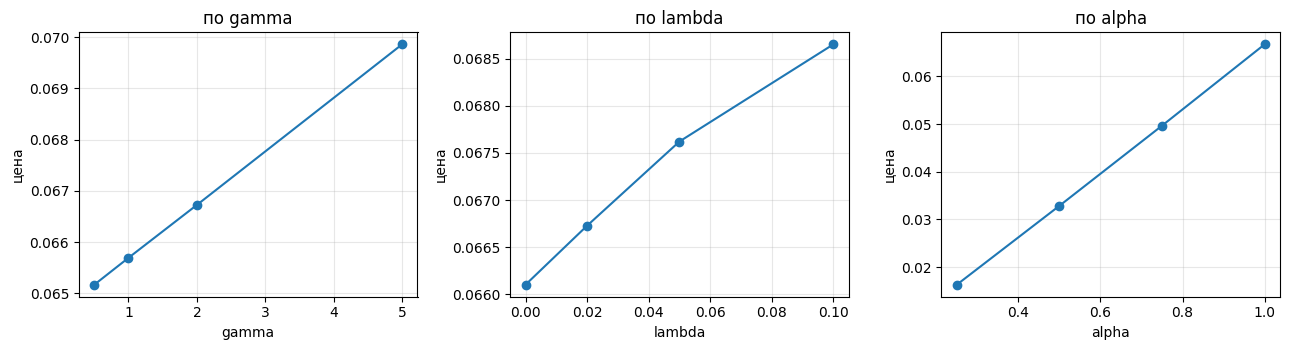

In [10]:
import pandas as pd
rows=[]
print("по gamma:")
for gm in [0.5,1.0,2.0,5.0]:
    p=price_c(gamma=gm); rows.append(('gamma',gm,p)); print(f"  {gm}: {p:.5f}")
print("по lambda:")
for lm in [0.0,0.02,0.05,0.10]:
    p=price_c(lam=lm); rows.append(('lambda',lm,p)); print(f"  {lm}: {p:.5f}")
print("по alpha:")
for al in [0.25,0.5,0.75,1.0]:
    p=price_c(alpha=al); rows.append(('alpha',al,p)); print(f"  {al}: {p:.5f}")
sens=pd.DataFrame(rows,columns=['param','value','price'])

fig,ax=plt.subplots(1,3,figsize=(13,3.6))
for k,nm in enumerate(['gamma','lambda','alpha']):
    d=sens[sens.param==nm]; ax[k].plot(d.value,d.price,'o-')
    ax[k].set_xlabel(nm); ax[k].set_ylabel('цена'); ax[k].grid(alpha=.3)
    ax[k].set_title(f'по {nm}')
plt.tight_layout(); plt.show()

Стресс-тесты (gamma=2.0):
  базовый               : 0.06673
  обвал цен (вол x2)    : 0.10349
  всплеск банкротств    : 0.06866
  распад корреляции     : 0.06857


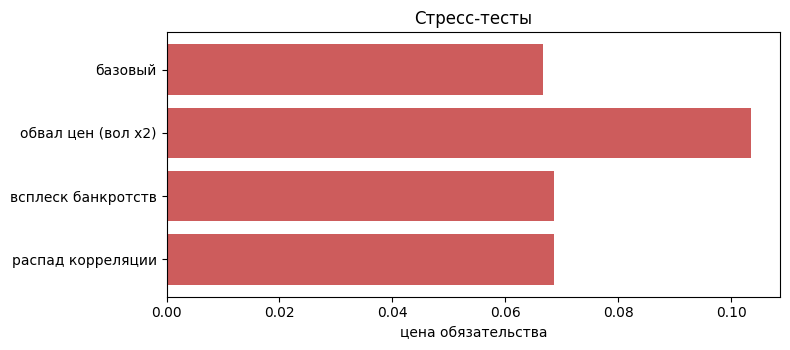

In [11]:
scen={'базовый':(SIGMA,LAM,RHO_H),
      'обвал цен (вол x2)':(2*SIGMA,LAM,RHO_H),
      'всплеск банкротств':(SIGMA,0.10,RHO_H),
      'распад корреляции':(SIGMA,LAM,0.5)}
print("Стресс-тесты (gamma=%.1f):"%GAMMA)
stress=[]
for nm,(s_,l_,rh_) in scen.items():
    p=price_c(sigma=s_,lam=l_,rho_h=rh_,gamma=GAMMA,alpha=1.0)
    stress.append((nm,p)); print(f"  {nm:22}: {p:.5f}")
plt.figure(figsize=(8,3.6))
plt.barh([s[0] for s in stress],[s[1] for s in stress],color='indianred')
plt.xlabel('цена обязательства'); plt.title('Стресс-тесты')
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

## 7. Сводка результатов для главы 4

In [12]:
print("="*60)
print("СВОДКА РЕЗУЛЬТАТОВ")
print("="*60)
print(f"Данные: {'реальные (Росстат)' if is_real else 'СИНТЕТИКА'}, "
      f"{len(prices)} кварталов")
print(f"Сглаживание phi={phi:.3f}; "
      f"sigma {SIGMA_OBS:.4f} -> {SIGMA_TRUE:.4f} (x{SIGMA_TRUE/SIGMA_OBS:.2f})")
print(f"Параметры: lambda={LAM}, eta={ETA}, rho_H={RHO_H}, gamma={GAMMA}")
print("-"*60)
for m in main_results:
    R=main_results[m]
    print(f"{m:6}: V_part={R['V_part']:.5f}  "
          f"(pi_a={R['pi_alpha']:.5f}, pi_0={R['pi_0']:.5f})")
print("-"*60)
print("Чувствительность и стресс-тесты — см. графики выше.")
print("Эти числа и графики переносятся в главу 4.")

СВОДКА РЕЗУЛЬТАТОВ
Данные: реальные (Росстат), 21 кварталов
Сглаживание phi=0.671; sigma 0.0437 -> 0.0879 (x2.01)
Параметры: lambda=0.02, eta=0.9, rho_H=0.8, gamma=2.0
------------------------------------------------------------
single: V_part=0.15509  (pi_a=0.83201, pi_0=0.67693)
annual: V_part=0.09467  (pi_a=0.87126, pi_0=0.77659)
------------------------------------------------------------
Чувствительность и стресс-тесты — см. графики выше.
Эти числа и графики переносятся в главу 4.


---
### Замечания для главы 4
- Все расчёты выполнены на **реальной десглаженной волатильности** из
  данных Росстата (не на учебных значениях).
- Десглаживание Гелтнера повышает $\sigma$ примерно вдвое — без него
  стоимость опционной части была бы существенно занижена.
- Единовременная премия даёт более дорогое участие, чем эквивалентная
  ежегодная (эффект усреднения входа).
- Цена растёт с $\gamma$, $\lambda$, $\alpha$; зависимость по $\alpha$
  близка к линейной (опционная декомпозиция, Утв. 1.2/2.3).
- На GPU увеличьте `M` и `EPOCHS` для более гладких кривых.